Exact ground energy: -15.322595
Iter 100: Energy = -13.238573, Fidelity = 0.470230
Iter 200: Energy = -15.184407, Fidelity = 0.913194
Iter 300: Energy = -15.308770, Fidelity = 0.995861
Iter 400: Energy = -15.320534, Fidelity = 0.999485
Iter 500: Energy = -15.322592, Fidelity = 0.999999
Iter 600: Energy = -15.322595, Fidelity = 1.000000

=== Final Results ===
Exact ground state energy E0            : -15.32259515
VQE ground state energy EVQE            : -15.32259515
Absolute error |EVQE − E0|              : 4.01101374e-12
Relative error ε                        : 0.000000%
Fidelity F = |⟨ψVQE|ψ0⟩|²               : 1.00000000
Number of qubits                        : 12
Number of variational parameters        : 12
Circuit depth (approx.)                 : 79
Two-qubit gate count                    : 72
Number of Pauli terms in Hamiltonian    : 24
Measurement settings (with grouping)    : 2
Total optimizer iterations             : 689
Function evaluations ≈                : 689
Wall-cloc

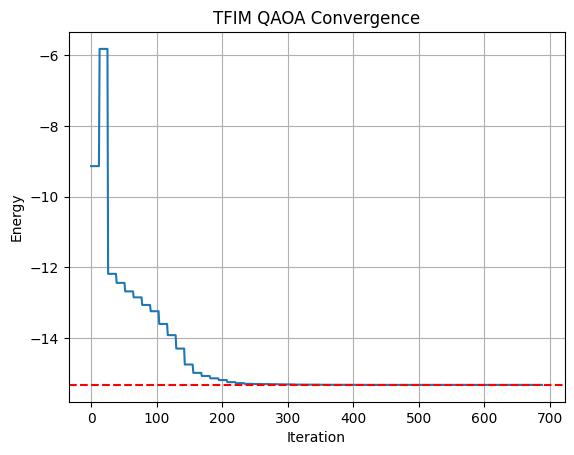

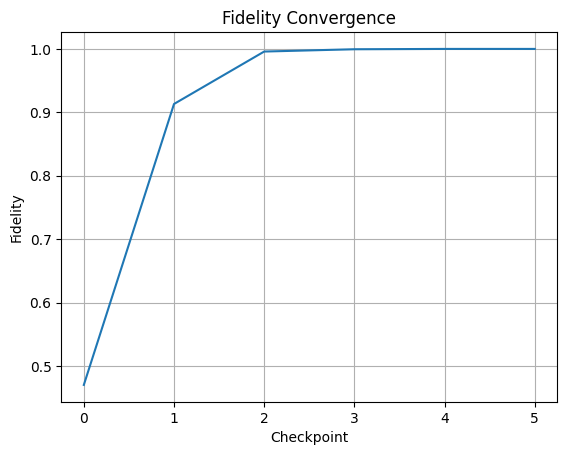

c:\Users\MicroTech\miniconda3\envs\vqe\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


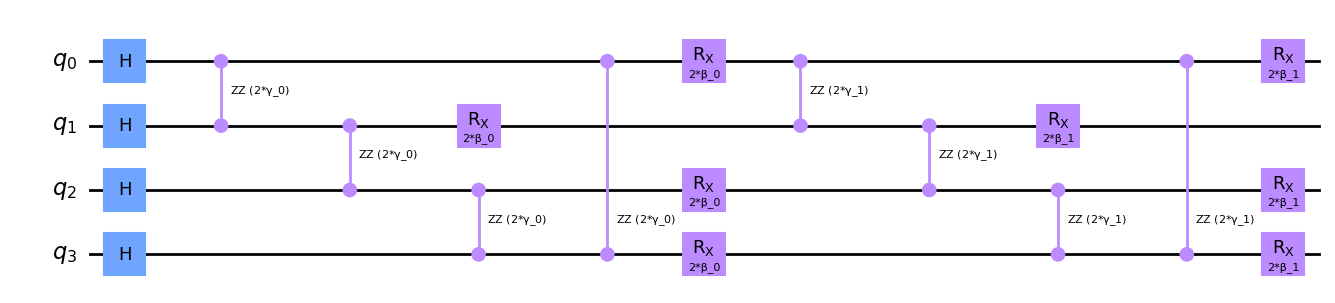

In [2]:

# 1. Import Libraries

import numpy as np
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B

np.random.seed(42)


# 2. TFIM Hamiltonian

def TFIM_ham(nqubits=12, J=1.0, h=1.0, periodic=True):
    pauli_list = []

    for i in range(nqubits - 1):
        pauli_list.append((f"I"*i + "ZZ" + "I"*(nqubits-i-2), -J))

    if periodic and nqubits > 1:
        pauli_list.append(("Z" + "I"*(nqubits-2) + "Z", -J))

    for i in range(nqubits):
        pauli_list.append((f"I"*i + "X" + "I"*(nqubits-i-1), -h))

    return SparsePauliOp.from_list(pauli_list)


# 3. TFIM Ansatz 

def TFIM_ansatz(nqubits, p=6):
    qc = QuantumCircuit(nqubits)

    qc.h(range(nqubits))  # |+>

    params = []

    for layer in range(p):

        # γ (ZZ)
        gamma = Parameter(f'γ_{layer}')
        for i in range(nqubits):
            j = (i + 1) % nqubits
            qc.rzz(2 * gamma, i, j)
        params.append(gamma)

        # β (X mixer)
        beta = Parameter(f'β_{layer}')
        for i in range(nqubits):
            qc.rx(2 * beta, i)
        params.append(beta)

    return qc, params


# 4. Exact Ground State

def compute_exact_energy(hamiltonian):
    mat = hamiltonian.to_matrix()
    eigvals, eigvecs = np.linalg.eigh(mat)

    exact_energy = float(np.min(eigvals))
    exact_state = eigvecs[:, np.argmin(eigvals)]

    print(f"Exact ground energy: {exact_energy:.6f}")
    return exact_energy, exact_state


# 5. VQE

def run_vqe(hamiltonian, nqubits, p, exact_energy, exact_state):

    ansatz, params = TFIM_ansatz(nqubits, p)
    initial_point = []
   
    for _ in range(p):
        initial_point.append(0.5)
        initial_point.append(np.pi/4)
    initial_point = np.array(initial_point)

    estimator = Estimator()
    optimizer = L_BFGS_B(maxiter=300)

    energy_history = []
    fidelity_history = []

    def callback(eval_count, parameters, mean, std):
        energy_history.append(mean)
        if eval_count % 100 == 0:
            circuit = ansatz.assign_parameters(parameters)
            state = Statevector.from_instruction(circuit)
            fid = abs(np.vdot(exact_state, state.data))**2
            fidelity_history.append(fid)
            print(f"Iter {eval_count:3d}: Energy = {mean:.6f}, Fidelity = {fid:.6f}")

    vqe = VQE(
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator,
        initial_point=initial_point,
        callback=callback,
    )

    start = time.time()
    result = vqe.compute_minimum_eigenvalue(hamiltonian)
    elapsed = time.time() - start

    final_energy = result.eigenvalue.real
    final_params = result.optimal_point

    final_circuit = ansatz.assign_parameters(final_params)
    final_state = Statevector.from_instruction(final_circuit)

    final_fidelity = abs(np.vdot(exact_state, final_state.data))**2
    relative_error = abs((final_energy - exact_energy)/abs(exact_energy))*100

  
    print("\n=== Final Results ===")
    print(f"Exact ground state energy E0            : {exact_energy:.8f}")
    print(f"VQE ground state energy EVQE            : {final_energy:.8f}")

    abs_error = abs(final_energy - exact_energy)
    print(f"Absolute error |EVQE − E0|              : {abs_error:.8e}")

    print(f"Relative error ε                        : {relative_error:.6f}%")
    print(f"Fidelity F = |⟨ψVQE|ψ0⟩|²               : {final_fidelity:.8f}")

    print(f"Number of qubits                        : {nqubits}")

    n_params = len(ansatz.parameters)
    print(f"Number of variational parameters        : {n_params}")

    depth = ansatz.depth()
    print(f"Circuit depth (approx.)                 : {depth}")

    two_qubit_gates = sum(1 for instr in ansatz.data if instr.operation.num_qubits == 2)
    print(f"Two-qubit gate count                    : {two_qubit_gates}")

    n_pauli_terms = len(hamiltonian)
    print(f"Number of Pauli terms in Hamiltonian    : {n_pauli_terms}")

    grouped = hamiltonian.group_commuting()
    n_measurement_settings = len(grouped)
    print(f"Measurement settings (with grouping)    : {n_measurement_settings}")

    print(f"Total optimizer iterations             : {len(energy_history)}")

    func_evals = len(energy_history)
    print(f"Function evaluations ≈                : {func_evals}")

    print(f"Wall-clock time (simulation)          : {elapsed:.2f} s")

    return final_energy, relative_error, final_fidelity, energy_history, fidelity_history, ansatz, final_params



# 6. Plotting

def plot_convergence(energy_history, exact_energy):
    plt.figure()
    plt.plot(energy_history)
    plt.axhline(y=exact_energy, linestyle='--', color='red')
    plt.xlabel('Iteration')
    plt.ylabel('Energy')
    plt.title('TFIM QAOA Convergence')
    plt.grid()
    plt.show()

def plot_fidelity(fid_history):
    if fid_history:
        plt.figure()
        plt.plot(fid_history)
        plt.xlabel('Checkpoint')
        plt.ylabel('Fidelity')
        plt.title('Fidelity Convergence')
        plt.grid()
        plt.show()


# 7. Main

nqubits = 12
J, h = 1.0, 1.0
p = 6

H = TFIM_ham(nqubits, J, h)

exact_energy, exact_state = compute_exact_energy(H)
vqe_energy, rel_err, final_fid, energy_hist, fid_hist, ansatz, final_params = run_vqe(
    H, nqubits, p, exact_energy, exact_state
)


plot_convergence(energy_hist, exact_energy)
plot_fidelity(fid_hist)

# draw 4-qubit 
demo_ansatz, _ = TFIM_ansatz(nqubits=4, p=2)
demo_ansatz.draw(output='mpl', fold=-1)

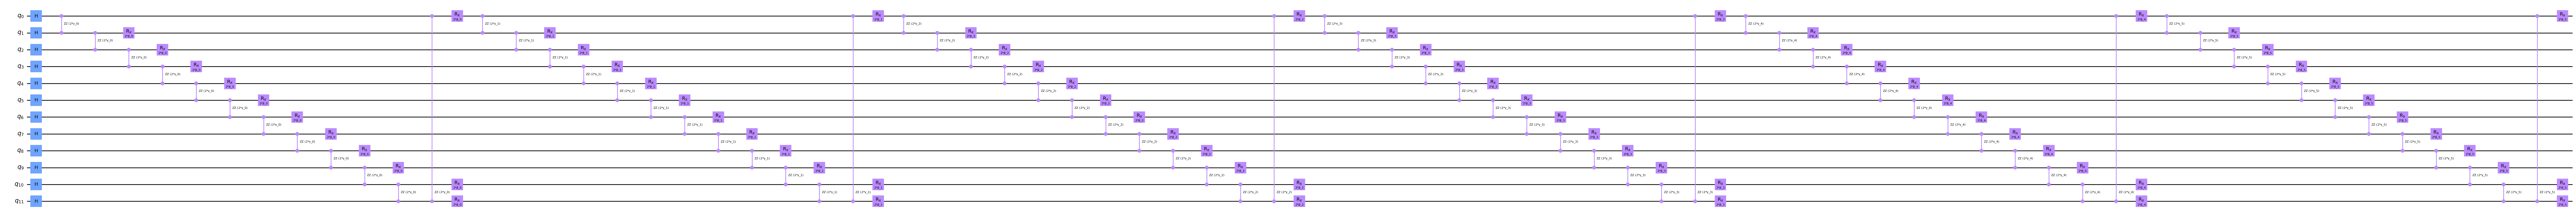

In [3]:
#draw the ansatz
ansatz.draw(output='mpl', fold=-1)



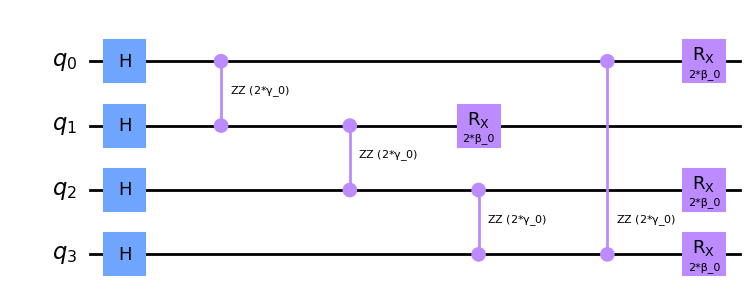

In [4]:
# draw 2-qubit 
demo_ansatz, _ = TFIM_ansatz(nqubits=4, p=1)
demo_ansatz.draw(output='mpl', fold=-1)